# BTC EMA Backtest Review — Gross vs Net Results

**Stage 5.3 — Performance Summary Notebook Integration**

Review one fixed BTCUSDT hourly sample, from 2025-10-01 00:00 UTC through
2026-09-30 23:00 UTC. This notebook calls the existing reusable functions:

**Local OHLCV → EMA strategy/execution pipeline → trade ledger → gross and
cost-aware accounting → CLOSED-trade performance summaries → cost analysis
and plots.**

The two accounting functions consume the same ledger independently. Net results
are not calculated by subtracting fees from the separate gross simulation.
Everything is historical research; no orders, real money, or data downloads are used.

## 1. Imports

Use the existing research environment. The project uses a `src/` layout, so add
that directory to the import path. The notebook works when started from the
project root or its `notebooks/` directory. All trading calculations remain in
the imported modules. `hashlib` checks that the local raw CSV stays unchanged.

The existing requests import can emit an urllib3/LibreSSL compatibility warning;
it is not suppressed. Reading the CSV makes no HTTP request.

In [1]:
from pathlib import Path
import hashlib
import sys

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "trading_lab").is_dir()
)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import load_ohlcv_csv
from trading_lab.backtest.pipeline import run_ema_execution_pipeline
from trading_lab.backtest.trades import build_trade_ledger
from trading_lab.backtest.performance import calculate_trade_results
from trading_lab.backtest.costs import calculate_trade_results_with_costs
from trading_lab.analytics.trade_metrics import (
    summarize_gross_trade_performance,
    summarize_net_trade_performance,
)

pd.set_option("display.max_columns", None)

/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Fixed research parameters

Keep EMA20/EMA50 and the 50-candle initialization period exactly as implemented.
No parameter optimization or search takes place here. The long-only spot model
allocates 100% of available capital to one trade at a time, with no leverage.

The net scenario assumes a **0.10% fee per side** and **0.05% adverse slippage
per side**. These are **research assumptions only**, not current Bybit fees.
The cost helper includes the entry fee in sizing, so the entry is self-financing.

In [2]:
FAST_SPAN = 20
SLOW_SPAN = 50
WARMUP_CANDLES = 50
INITIAL_CAPITAL = 10_000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005

START = pd.Timestamp("2025-10-01 00:00", tz="UTC")
END = pd.Timestamp("2026-10-01 00:00", tz="UTC")  # Exclusive.
EXPECTED_CANDLES = 8_760
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"

print(f"EMA spans: {FAST_SPAN}/{SLOW_SPAN}; warm-up: {WARMUP_CANDLES} candles")
print(f"Starting capital: {INITIAL_CAPITAL:,.2f} USDT")
print(f"Research fee: {FEE_RATE:.2%} per side; adverse slippage: {SLIPPAGE_RATE:.2%} per side")

EMA spans: 20/50; warm-up: 50 candles
Starting capital: 10,000.00 USDT
Research fee: 0.10% per side; adverse slippage: 0.05% per side


## 3. Load the existing BTC snapshot

Load and validate the local file with the Stage 1 loader. If it is absent,
stop with a clear error rather than downloading a replacement. The loader
restores UTC timestamps and numeric dtypes and validates the requested hourly
coverage. We do not repeat that validation system or save transformed data.

In [3]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"Required local snapshot is missing: {CSV_PATH}")

raw_hash_before = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
candles = load_ohlcv_csv(CSV_PATH, interval="60", start=START, end=END)
candles_before = candles.copy(deep=True)
print("Loaded local snapshot:", CSV_PATH.name)

Loaded local snapshot: BTCUSDT_1h.csv


## 4. Dataset sanity checks

Timestamps label candle **opening** times. Show the dataset size/range, missing
values in the six required OHLCV columns, and duplicate timestamps. Assertions
below are reference checks for this saved sample, not inputs to strategy calculations.

In [4]:
required_columns = ["timestamp", "open", "high", "low", "close", "volume"]
dataset_summary = pd.Series({
    "Candles": len(candles),
    "First timestamp": candles["timestamp"].iloc[0],
    "Last timestamp": candles["timestamp"].iloc[-1],
    "Duplicate timestamps": int(candles["timestamp"].duplicated().sum()),
}, name="Observed")
display(dataset_summary.to_frame())
display(candles[required_columns].isna().sum().rename("Missing values").to_frame())

assert len(candles) == EXPECTED_CANDLES, "Unexpected snapshot row count"
assert candles["timestamp"].iloc[0] == START, "Unexpected first candle"
assert candles["timestamp"].iloc[-1] == END - pd.Timedelta(hours=1), "Unexpected last candle"
display(candles.head(3))

,Observed
Candles,8760
First timestamp,2025-10-01 00:00:00+00:00
Last timestamp,2026-09-30 23:00:00+00:00
Duplicate timestamps,0


,Missing values
timestamp,0
open,0
high,0
low,0
close,0
volume,0


,timestamp,open,high,low,close,volume
0,2025-10-01 00:00:00+00:00,114051.1,114300.3,113962.3,114241.0,256.712737
1,2025-10-01 01:00:00+00:00,114241.0,114550.0,114142.2,114549.4,240.479371
2,2025-10-01 02:00:00+00:00,114549.4,114551.9,114252.4,114275.5,219.500905


## 5. Run the strategy/execution pipeline

Stage 4.4 calls the separate EMA strategy and next-open execution helpers.
The first 50 candles initialize the strategy; eligible signals start on candle 51.
This table has one row per candle and contains intent and recorded fill metadata,
but no trade pairing or financial results yet.

In [5]:
pipeline_df = run_ema_execution_pipeline(
    candles, fast_span=FAST_SPAN, slow_span=SLOW_SPAN,
    warmup_candles=WARMUP_CANDLES,
)
pipeline_before = pipeline_df.copy(deep=True)
print("Pipeline shape:", pipeline_df.shape)
print("Pipeline columns:", pipeline_df.columns.tolist())

Pipeline shape: (8760, 14)
Pipeline columns: ['timestamp', 'open', 'close', 'ema_20', 'ema_50', 'warmup_complete', 'bullish_cross', 'bearish_cross', 'signal', 'desired_position', 'signal_time', 'execution_time', 'execution_price', 'executed_position']


## 6. Inspect signals and executions

`desired_position` is intent after a candle completes; `executed_position`
is the position held during that candle. On a signal row N, execution time/price
describe the fill at N+1's OPEN, so the row's own signal does not immediately
change its held position. Signal availability and execution share the same
hourly boundary timestamp, with completion → signal → fill as the causal order.
See [decision 002](../decisions/002_backtest_execution_contract.md).

A signal alone is not proof of a fill: a final-candle event without a next
candle has no execution metadata. Inspect actual executed events below.

In [6]:
entry_count = int(pipeline_df["signal"].eq("LONG_ENTRY").sum())
exit_count = int(pipeline_df["signal"].eq("LONG_EXIT").sum())
final_desired = int(pipeline_df["desired_position"].iloc[-1])
final_executed = int(pipeline_df["executed_position"].iloc[-1])
display(pd.Series({
    "LONG_ENTRY signals": entry_count,
    "LONG_EXIT signals": exit_count,
    "Final desired_position": final_desired,
    "Final executed_position": final_executed,
}, name="Observed").to_frame())

executed_events = pipeline_df.loc[pipeline_df["execution_time"].notna()]
first_entry = executed_events.loc[executed_events["signal"].eq("LONG_ENTRY")].iloc[0]
first_exit = executed_events.loc[executed_events["signal"].eq("LONG_EXIT")].iloc[0]
event_columns = [
    "timestamp", "signal_time", "signal", "execution_time", "execution_price",
    "desired_position", "executed_position",
]
display(pd.DataFrame([first_entry, first_exit])[event_columns])

# Fixed-snapshot references: fail and investigate, never repair the output.
assert (entry_count, exit_count, final_desired, final_executed) == (78, 77, 1, 1)
assert first_entry["execution_time"] == pd.Timestamp("2025-10-13 03:00", tz="UTC")
assert first_exit["execution_time"] == pd.Timestamp("2025-10-14 06:00", tz="UTC")
np.testing.assert_allclose(first_entry["execution_price"], 115_332.3)
np.testing.assert_allclose(first_exit["execution_price"], 112_482.0)

,Observed
LONG_ENTRY signals,78
LONG_EXIT signals,77
Final desired_position,1
Final executed_position,1


,timestamp,signal_time,signal,execution_time,execution_price,desired_position,executed_position
290,2025-10-13 02:00:00+00:00,2025-10-13 03:00:00+00:00,LONG_ENTRY,2025-10-13 03:00:00+00:00,115332.3,1,0
317,2025-10-14 05:00:00+00:00,2025-10-14 06:00:00+00:00,LONG_EXIT,2025-10-14 06:00:00+00:00,112482.0,0,1


## 7. Build the trade ledger

Stage 4.5 pairs **recorded fills**, using their prices and times. Each executed
entry creates one trade. An executed exit makes it CLOSED; an entry with no exit
remains OPEN. The ledger does not invent an exit when the dataset ends.

In [7]:
trades = build_trade_ledger(pipeline_df)
trades_before = trades.copy(deep=True)
closed_count = int(trades["status"].eq("CLOSED").sum())
open_count = int(trades["status"].eq("OPEN").sum())
display(pd.Series({
    "Total trades": len(trades), "CLOSED trades": closed_count, "OPEN trades": open_count,
}, name="Observed").to_frame())
assert (closed_count, open_count) == (77, 1), "Unexpected trade pairing"

,Observed
Total trades,78
CLOSED trades,77
OPEN trades,1


## 8. Inspect first and last trades

One row now represents a trade rather than a candle. `trade_id` starts at 1.
The final row has missing exit time/price because it is still OPEN.
These six recorded ledger columns will remain unchanged in both accounting outputs.

In [8]:
print("First five trades:")
display(trades.head(5))
print("Last five trades:")
display(trades.tail(5))

First five trades:


,trade_id,entry_time,entry_price,exit_time,exit_price,status
0,1,2025-10-13 03:00:00+00:00,115332.3,2025-10-14 06:00:00+00:00,112482.0,CLOSED
1,2,2025-10-19 16:00:00+00:00,108490.4,2025-10-21 10:00:00+00:00,107751.4,CLOSED
2,3,2025-10-21 15:00:00+00:00,112199.9,2025-10-22 04:00:00+00:00,108217.7,CLOSED
3,4,2025-10-23 12:00:00+00:00,109258.6,2025-10-29 01:00:00+00:00,112432.7,CLOSED
4,5,2025-11-01 17:00:00+00:00,110467.3,2025-11-03 02:00:00+00:00,109668.3,CLOSED


Last five trades:


,trade_id,entry_time,entry_price,exit_time,exit_price,status
73,74,2026-09-14 07:00:00+00:00,77597.2,2026-09-15 10:00:00+00:00,76973.0,CLOSED
74,75,2026-09-17 16:00:00+00:00,76786.4,2026-09-23 21:00:00+00:00,84241.8,CLOSED
75,76,2026-09-27 03:00:00+00:00,84452.9,2026-09-28 03:00:00+00:00,83421.4,CLOSED
76,77,2026-09-29 14:00:00+00:00,84206.0,2026-09-29 16:00:00+00:00,83072.2,CLOSED
77,78,2026-09-30 13:00:00+00:00,85293.8,NaT,NaN,OPEN


## 9. Calculate zero-cost gross results

Call Stage 4.6 separately. It sizes each trade using capital available before
entry and compounds the result of each CLOSED trade into the next trade.
The model has zero fees and slippage, and no quantity rounding or leverage.

The compact table shows the first and last three trades. OPEN quantity is known,
but its realized return, PnL, and capital after remain missing. `capital_before`
is capital available **before** the entry, not cash remaining after allocation.

In [9]:
gross_results = calculate_trade_results(trades, initial_capital=INITIAL_CAPITAL)
gross_closed = gross_results.loc[gross_results["status"].eq("CLOSED")].copy()
gross_columns = [
    "trade_id", "entry_time", "exit_time", "status", "capital_before",
    "quantity", "trade_return", "gross_pnl", "capital_after",
]
gross_preview = pd.concat([gross_results.head(3), gross_results.tail(3)])
display(gross_preview[gross_columns].style.format({
    "capital_before": "{:,.6f}", "quantity": "{:.12f}", "trade_return": "{:.4%}",
    "gross_pnl": "{:,.6f}", "capital_after": "{:,.6f}",
}, na_rep="—"))

final_gross_capital = float(gross_closed["capital_after"].iloc[-1])
gross_realized_change = final_gross_capital - INITIAL_CAPITAL
gross_realized_return = gross_realized_change / INITIAL_CAPITAL
print(f"Starting capital: {INITIAL_CAPITAL:,.6f} USDT")
print(f"Final CLOSED-trade gross capital: {final_gross_capital:,.9f} USDT")
print(f"Gross realized change: {gross_realized_change:,.9f} USDT")
print(f"Gross realized return: {gross_realized_return:.6%}")
np.testing.assert_allclose(final_gross_capital, 9_641.111388344, rtol=1e-10)

,trade_id,entry_time,exit_time,status,capital_before,quantity,trade_return,gross_pnl,capital_after
0,1,2025-10-13 03:00:00+00:00,2025-10-14 06:00:00+00:00,CLOSED,"10,000.000000",0.086705979158,-2.4714%,-247.138052,"9,752.861948"
1,2,2025-10-19 16:00:00+00:00,2025-10-21 10:00:00+00:00,CLOSED,"9,752.861948",0.089896082488,-0.6812%,-66.433205,"9,686.428743"
2,3,2025-10-21 15:00:00+00:00,2025-10-22 04:00:00+00:00,CLOSED,"9,686.428743",0.086331883920,-3.5492%,-343.790828,"9,342.637915"
75,76,2026-09-27 03:00:00+00:00,2026-09-28 03:00:00+00:00,CLOSED,"9,893.535569",0.117148559358,-1.2214%,-120.838739,"9,772.696830"
76,77,2026-09-29 14:00:00+00:00,2026-09-29 16:00:00+00:00,CLOSED,"9,772.696830",0.116057012916,-1.3465%,-131.585441,"9,641.111388"
77,78,2026-09-30 13:00:00+00:00,—,OPEN,"9,641.111388",0.113034140680,—,—,—


Starting capital: 10,000.000000 USDT
Final CLOSED-trade gross capital: 9,641.111388344 USDT
Gross realized change: -358.888611656 USDT
Gross realized return: -3.588886%


## 10. Calculate cost-aware net results

Call Stage 4.7 on the same ledger with the fixed research rates. The helper
applies adverse entry/exit slippage, fees on effective notionals, and self-financing
entry sizing. Net capital compounds after CLOSED trades. We inspect existing
columns rather than implement these calculations again.

Two compact views separate sizing/fees from PnL, keeping the tables readable.
Here `gross_pnl` uses the **cost-sized quantity** and recorded prices. It is not
the PnL from the separate Stage 4.6 simulation, whose quantities differ.

In [10]:
net_results = calculate_trade_results_with_costs(
    trades, initial_capital=INITIAL_CAPITAL,
    fee_rate=FEE_RATE, slippage_rate=SLIPPAGE_RATE,
)
net_closed = net_results.loc[net_results["status"].eq("CLOSED")].copy()
net_preview = pd.concat([net_results.head(3), net_results.tail(3)])
sizing_columns = [
    "trade_id", "status", "capital_before", "quantity", "entry_fee", "exit_fee", "total_fees",
]
pnl_columns = [
    "trade_id", "status", "gross_pnl", "price_adjusted_pnl", "net_pnl",
    "net_trade_return", "net_capital_after",
]
display(net_preview[sizing_columns].style.format({
    "capital_before": "{:,.6f}", "quantity": "{:.12f}",
    "entry_fee": "{:,.6f}", "exit_fee": "{:,.6f}", "total_fees": "{:,.6f}",
}, na_rep="—"))
display(net_preview[pnl_columns].style.format({
    "gross_pnl": "{:,.6f}", "price_adjusted_pnl": "{:,.6f}", "net_pnl": "{:,.6f}",
    "net_trade_return": "{:.4%}", "net_capital_after": "{:,.6f}",
}, na_rep="—"))

final_net_capital = float(net_closed["net_capital_after"].iloc[-1])
net_realized_change = final_net_capital - INITIAL_CAPITAL
net_realized_return = net_realized_change / INITIAL_CAPITAL
print(f"Starting capital: {INITIAL_CAPITAL:,.6f} USDT")
print(f"Final CLOSED-trade net capital: {final_net_capital:,.9f} USDT")
print(f"Net realized change: {net_realized_change:,.9f} USDT")
print(f"Net realized return: {net_realized_return:.6%}")
np.testing.assert_allclose(final_net_capital, 7_652.530163437, rtol=1e-10)

,trade_id,status,capital_before,quantity,entry_fee,exit_fee,total_fees
0,1,CLOSED,"10,000.000000",0.086576071762,9.990010,9.733381,19.723391
1,2,CLOSED,"9,723.647198",0.089492514783,9.713933,9.638122,19.352056
2,3,CLOSED,"9,628.484163",0.085686870210,9.618865,9.268200,18.887065
75,76,CLOSED,"7,900.148168",0.093404865389,7.892256,7.788069,15.680325
76,77,CLOSED,"7,780.280587",0.092257366062,7.772508,7.660190,15.432698
77,78,OPEN,"7,652.530163",0.089585230647,7.644885,—,—


,trade_id,status,gross_pnl,price_adjusted_pnl,net_pnl,net_trade_return,net_capital_after
0,1,CLOSED,-246.767777,-256.629411,-276.352802,-2.7635%,"9,723.647198"
1,2,CLOSED,-66.134968,-75.810980,-95.163035,-0.9787%,"9,628.484163"
2,3,CLOSED,-341.222255,-350.665702,-369.552767,-3.8381%,"9,258.931397"
75,76,CLOSED,-96.347119,-104.187257,-119.867581,-1.5173%,"7,780.280587"
76,77,CLOSED,-104.601402,-112.317725,-127.750423,-1.6420%,"7,652.530163"
77,78,OPEN,—,—,—,—,—


Starting capital: 10,000.000000 USDT
Final CLOSED-trade net capital: 7,652.530163437 USDT
Net realized change: -2,347.469836563 USDT
Net realized return: -23.474698%


## 11. Compare gross vs net

Compare both independently compounded simulations from the same starting
capital and recorded trades. Realized return here means change from starting
capital divided by starting capital; it is not annualized or a sum of trade returns.

The final-capital difference includes **fees, slippage, and their compounded
impact on later position sizing**. It is not simply the sum of fees. These are
values after the last CLOSED trade and before the final OPEN entry, not portfolio
ending values.

In [11]:
comparison = pd.DataFrame({
    "Gross": [INITIAL_CAPITAL, final_gross_capital, gross_realized_change, gross_realized_return],
    "Net": [INITIAL_CAPITAL, final_net_capital, net_realized_change, net_realized_return],
}, index=["Starting capital (USDT)", "Final realized capital (USDT)",
          "Realized change (USDT)", "Realized return"])
comparison.index.name = "Metric"
display(comparison.style.format("{:,.6f}").format("{:.6%}", subset=pd.IndexSlice[["Realized return"], :]))

capital_difference = final_gross_capital - final_net_capital
print(f"Gross minus net final realized capital: {capital_difference:,.9f} USDT")
np.testing.assert_allclose(capital_difference, 1_988.581224907, rtol=1e-10)

,Gross,Net
Metric,,
Starting capital (USDT),"10,000.000000","10,000.000000"
Final realized capital (USDT),"9,641.111388","7,652.530163"
Realized change (USDT),-358.888612,"-2,347.469837"
Realized return,-3.588886%,-23.474698%


Gross minus net final realized capital: 1,988.581224907 USDT


## 12. Plot realized capital by completed trade

Trade 0 is the starting capital before the first entry. Each later point is
capital after a CLOSED trade. The lines connect these observations for readability;
the horizontal axis is completed trade number, not elapsed time.

This is **trade-by-trade realized capital**, not a candle-level portfolio equity
curve. OPEN positions and within-trade price movements are not valued.

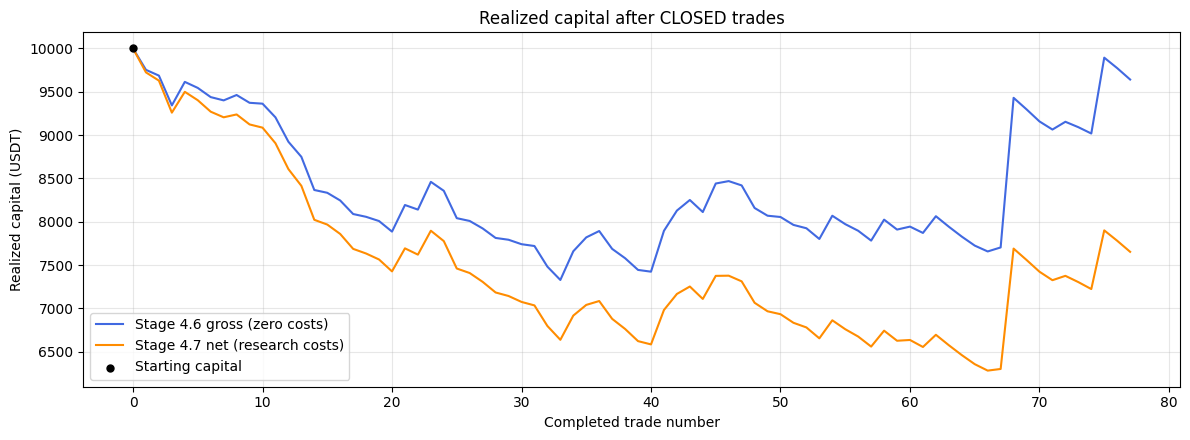

In [12]:
pd.testing.assert_series_equal(gross_closed["trade_id"], net_closed["trade_id"])
completed_trade_numbers = [0, *gross_closed["trade_id"].tolist()]
gross_capital_points = [INITIAL_CAPITAL, *gross_closed["capital_after"].tolist()]
net_capital_points = [INITIAL_CAPITAL, *net_closed["net_capital_after"].tolist()]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(completed_trade_numbers, gross_capital_points, label="Stage 4.6 gross (zero costs)", color="royalblue")
ax.plot(completed_trade_numbers, net_capital_points, label="Stage 4.7 net (research costs)", color="darkorange")
ax.scatter([0], [INITIAL_CAPITAL], color="black", s=25, zorder=4, label="Starting capital")
ax.set(title="Realized capital after CLOSED trades", xlabel="Completed trade number", ylabel="Realized capital (USDT)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 13. CLOSED-trade performance summary

Call the Stage 5.2 analytics functions on the **existing** `gross_results`
and `net_results`. [Decision 003](../decisions/003_closed_trade_performance_metrics.md)
defines the 16 metrics; their formulas stay in the reusable module.
GROSS uses Stage 4.6 zero-cost returns/PnL. NET uses Stage 4.7 net
returns/PnL, with its own cost-aware sizing and compounding.

Only CLOSED trades enter this table. The final OPEN trade contributes
nothing to counts, rates, averages, expectancy, or profit factor and remains
unvalued. Percentages, USDT amounts, and rounded ratios below are **display
formatting only**; the summaries retain their full-precision values.

In [13]:
gross_before_metrics = gross_results.copy(deep=True)
net_before_metrics = net_results.copy(deep=True)
gross_summary = summarize_gross_trade_performance(gross_results)
net_summary = summarize_net_trade_performance(net_results)

metric_labels = {
    "closed_trade_count": "CLOSED trades",
    "winning_trade_count": "Winning trades",
    "losing_trade_count": "Losing trades",
    "breakeven_trade_count": "Breakeven trades",
    "win_rate": "Win rate",
    "loss_rate": "Loss rate",
    "breakeven_rate": "Breakeven rate",
    "average_trade_return": "Average trade return",
    "median_trade_return": "Median trade return",
    "average_win_return": "Average winning return",
    "average_loss_return": "Average losing return",
    "best_trade_return": "Best trade return",
    "worst_trade_return": "Worst trade return",
    "total_realized_pnl": "Total realized PnL",
    "expectancy_pnl": "Sample expectancy per CLOSED trade",
    "profit_factor": "Profit factor",
}
performance_table = pd.concat([gross_summary, net_summary]).T.rename(
    index=metric_labels, columns={"GROSS": "Gross", "NET": "Net"},
)
performance_table.index.name = "Metric"
display(performance_table.style.format("{:.6f}", na_rep="—")
    .format("{:,.0f}", subset=pd.IndexSlice[list(metric_labels.values())[:4], :])
    .format("{:.6%}", subset=pd.IndexSlice[list(metric_labels.values())[4:13], :])
    .format("{:,.6f} USDT", subset=pd.IndexSlice[list(metric_labels.values())[13:15], :]))

,Gross,Net
Metric,,
CLOSED trades,77,77
Winning trades,20,20
Losing trades,57,57
Breakeven trades,0,0
Win rate,25.974026%,25.974026%
Loss rate,74.025974%,74.025974%
Breakeven rate,0.000000%,0.000000%
Average trade return,0.007059%,-0.292513%
Median trade return,-0.873529%,-1.170463%


## 14. Read the metrics and compare gross vs net

**WIN / LOSS / BREAKEVEN** use each path's unrounded trade return:
above +`1e-12` is WIN, below -`1e-12` is LOSS, and inside or on those
boundaries is BREAKEVEN. Formatting a tiny return as 0% does not change
its classification. **Win rate** is the share of CLOSED trades classed WIN.
A low win rate can still work if winners are sufficiently larger than
losers; it does not establish profitability on its own.

**Average trade return** is the arithmetic mean across CLOSED trades,
including breakevens. **Average winning/losing return** uses only that
path's WIN/LOSS subset. Returns normalize trades for comparison and
determine classification. PnL records realized USDT on the capital actually
allocated, and supplies total PnL, expectancy, and profit factor.

**Sample expectancy** is historical average realized PnL per CLOSED trade.
It describes this sample; it is not a prediction, a probability forecast,
or guaranteed future profit/loss. **Profit factor** compares the sum of
WIN PnL with the absolute sum of LOSS PnL: above 1 means winning PnL
exceeds losing PnL, 1 means equal, and below 1 means losses exceed wins.
Breakeven residuals remain in totals/expectancy but not these two aggregates.

Arithmetic average return and compounded strategy return describe different
things. Capital follows the sequence of trades: each return acts on capital
left by previous trades, rather than on the same starting amount. Losses and
gains do not cancel arithmetically; a loss leaves less capital for the next
trade. Compounding can therefore finish below the starting capital despite
a slightly positive arithmetic average. In this full-allocation, fixed-rate
model, reordering the same returns would not change their final product.

In [14]:
gross_metrics = gross_summary.loc["GROSS"]
net_metrics = net_summary.loc["NET"]
display(Markdown(
    f"**This BTC sample:** both paths have **{int(gross_metrics['winning_trade_count'])} "
    f"wins / {int(gross_metrics['closed_trade_count'])} CLOSED trades**, a win rate of "
    f"**{gross_metrics['win_rate']:.2%}**, with **{int(gross_metrics['losing_trade_count'])} "
    f"losses** and **{int(gross_metrics['breakeven_trade_count'])} breakevens**. "
    "Costs happened to leave classification unchanged here; another sample could "
    "turn a gross WIN into a net LOSS.\n\n"
    f"Average winning return falls from **{gross_metrics['average_win_return']:+.2%}** "
    f"gross to **{net_metrics['average_win_return']:+.2%}** net; average losing return "
    f"worsens from **{gross_metrics['average_loss_return']:+.2%}** to "
    f"**{net_metrics['average_loss_return']:+.2%}**. Average trade return falls from "
    f"**{gross_metrics['average_trade_return']:+.6%}** to "
    f"**{net_metrics['average_trade_return']:+.6%}**.\n\n"
    f"Profit factor falls from **{gross_metrics['profit_factor']:.3f}** to "
    f"**{net_metrics['profit_factor']:.3f}**. Both are below 1: winning PnL did not "
    "fully compensate for losing PnL in this sample. Total realized PnL is "
    f"**{gross_metrics['total_realized_pnl']:,.2f} USDT** gross and "
    f"**{net_metrics['total_realized_pnl']:,.2f} USDT** net. Sample expectancy worsens "
    f"from **{gross_metrics['expectancy_pnl']:,.2f} USDT** to "
    f"**{net_metrics['expectancy_pnl']:,.2f} USDT per CLOSED trade**.\n\n"
    f"The gross arithmetic average is slightly positive "
    f"(**{gross_metrics['average_trade_return']:+.6%}**), yet gross realized capital "
    f"ends at **{final_gross_capital:,.2f} USDT**, below **{INITIAL_CAPITAL:,.2f} USDT**. "
    f"After modeled costs, final realized capital falls further to "
    f"**{final_net_capital:,.2f} USDT**. These observations describe this historical "
    "sample under the stated assumptions; they do not establish general strategy quality."
))

**This BTC sample:** both paths have **20 wins / 77 CLOSED trades**, a win rate of **25.97%**, with **57 losses** and **0 breakevens**. Costs happened to leave classification unchanged here; another sample could turn a gross WIN into a net LOSS.

Average winning return falls from **+3.87%** gross to **+3.55%** net; average losing return worsens from **-1.35%** to **-1.64%**. Average trade return falls from **+0.007059%** to **-0.292513%**.

Profit factor falls from **0.945** to **0.675**. Both are below 1: winning PnL did not fully compensate for losing PnL in this sample. Total realized PnL is **-358.89 USDT** gross and **-2,347.47 USDT** net. Sample expectancy worsens from **-4.66 USDT** to **-30.49 USDT per CLOSED trade**.

The gross arithmetic average is slightly positive (**+0.007059%**), yet gross realized capital ends at **9,641.11 USDT**, below **10,000.00 USDT**. After modeled costs, final realized capital falls further to **7,652.53 USDT**. These observations describe this historical sample under the stated assumptions; they do not establish general strategy quality.

## 15. Check summary regressions and OPEN exclusion

The fixed references below validate this saved BTC sample; they never supply
calculation outputs. A mismatch stops execution for investigation. Compare
each summary with the same helper called on its existing CLOSED-only view:
removing the final OPEN row must leave **all 16 metrics identical**.
Also confirm analytics did not change either accounting input.

In [15]:
count_columns = [
    "closed_trade_count", "winning_trade_count", "losing_trade_count", "breakeven_trade_count",
]
for summary, label in [(gross_summary, "GROSS"), (net_summary, "NET")]:
    assert tuple(summary.loc[label, count_columns]) == (77, 20, 57, 0)

reference_columns = [
    "win_rate", "loss_rate", "breakeven_rate", "average_trade_return", "median_trade_return",
    "average_win_return", "average_loss_return", "best_trade_return", "worst_trade_return",
    "total_realized_pnl", "expectancy_pnl", "profit_factor",
]
gross_reference = [
    .259740259740, .740259740260, 0.0, .000070588288, -.008735290732,
    .038651616726, -.013466614673, .224171061391, -.043755772679,
    -358.888611656, -4.660891060, .945165760246,
]
net_reference = [
    .259740259740, .740259740260, 0.0, -.002925128404, -.011704629367,
    .035540330361, -.016421780603, .220504050556, -.046620207277,
    -2347.469836563, -30.486621254, .675088667158,
]
np.testing.assert_allclose(gross_summary.loc["GROSS", reference_columns], gross_reference, rtol=1e-10, atol=1e-9)
np.testing.assert_allclose(net_summary.loc["NET", reference_columns], net_reference, rtol=1e-10, atol=1e-9)

assert gross_results["status"].iloc[-1] == net_results["status"].iloc[-1] == "OPEN"
pd.testing.assert_frame_equal(gross_summary, summarize_gross_trade_performance(gross_closed))
pd.testing.assert_frame_equal(net_summary, summarize_net_trade_performance(net_closed))
pd.testing.assert_frame_equal(gross_results, gross_before_metrics)
pd.testing.assert_frame_equal(net_results, net_before_metrics)
print("All 16 gross/net references passed; OPEN exclusion and accounting-input preservation passed.")

All 16 gross/net references passed; OPEN exclusion and accounting-input preservation passed.


## 16. Inspect transaction costs

Use **CLOSED trades only**. Sum/average the fee columns already produced by Stage
4.7. Modelled slippage impact is `gross_pnl - price_adjusted_pnl`, using that
same cost-aware simulation's quantity; it is positive when adverse prices reduce PnL.

The final OPEN entry fee is excluded from these round-trip summaries and shown
separately below. These descriptive calculations stay in the notebook. Fees plus
slippage on this sizing path do not equal the final-capital gap between the two
simulations, because their later quantities differ.

In [16]:
modeled_slippage_impact = net_closed["gross_pnl"] - net_closed["price_adjusted_pnl"]
entry_fee_sum = float(net_closed["entry_fee"].sum())
exit_fee_sum = float(net_closed["exit_fee"].sum())
total_fee_sum = float(net_closed["total_fees"].sum())
average_total_fee = float(net_closed["total_fees"].mean())
total_slippage_impact = float(modeled_slippage_impact.sum())
average_slippage_impact = float(modeled_slippage_impact.mean())

cost_summary = pd.Series({
    "Sum of entry fees": entry_fee_sum,
    "Sum of exit fees": exit_fee_sum,
    "Sum of total fees": total_fee_sum,
    "Average total fee per CLOSED trade": average_total_fee,
    "Total modeled slippage impact": total_slippage_impact,
    "Average modeled slippage impact per CLOSED trade": average_slippage_impact,
}, name="USDT — CLOSED trades only")
display(cost_summary.to_frame().style.format("{:,.9f}"))

,USDT — CLOSED trades only
Sum of entry fees,577.318661158
Sum of exit fees,576.124634617
Sum of total fees,"1,153.443295774"
Average total fee per CLOSED trade,14.979783062
Total modeled slippage impact,576.721493561
Average modeled slippage impact per CLOSED trade,7.489889527


## 17. Visualize accumulated modeled costs

Show cumulative fees and cumulative fees plus modeled slippage on the Stage 4.7
quantity path. Their separation shows the accumulated slippage component.
These lines are descriptive sums across CLOSED trades, not another execution
model or the gross/net final-capital gap. This complements the capital chart.

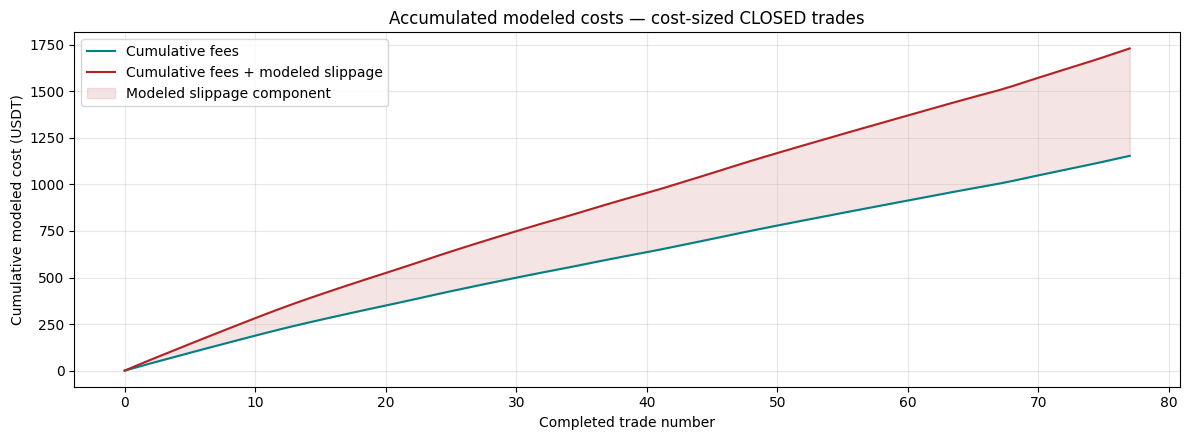

In [17]:
cumulative_fees = net_closed["total_fees"].cumsum()
cumulative_direct_costs = (net_closed["total_fees"] + modeled_slippage_impact).cumsum()
cost_trade_numbers = [0, *net_closed["trade_id"].tolist()]
fee_points = [0.0, *cumulative_fees.tolist()]
direct_cost_points = [0.0, *cumulative_direct_costs.tolist()]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(cost_trade_numbers, fee_points, label="Cumulative fees", color="teal")
ax.plot(cost_trade_numbers, direct_cost_points, label="Cumulative fees + modeled slippage", color="firebrick")
ax.fill_between(cost_trade_numbers, fee_points, direct_cost_points, color="firebrick", alpha=0.12, label="Modeled slippage component")
ax.set(title="Accumulated modeled costs — cost-sized CLOSED trades", xlabel="Completed trade number", ylabel="Cumulative modeled cost (USDT)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 18. First trade walkthrough

Read all values directly from the existing outputs. Adverse slippage increases
the effective LONG entry price and reduces the effective exit price. Self-financing
sizing leaves room for the entry fee; the exit fee reduces sale proceeds further.
Therefore net PnL is below the recorded-price gross PnL for this quantity.

The last two rows show the net return and net capital after closing. The separate
zero-cost gross PnL is shown for reference; it uses a different quantity.
Prices, fees, PnL, and capital use USDT; quantity uses BTC; return is decimal.

In [18]:
first_net_trade = net_closed.iloc[0]
first_trade_fields = [
    "entry_price", "effective_entry_price", "exit_price", "effective_exit_price",
    "quantity", "entry_fee", "exit_fee", "total_fees", "gross_pnl",
    "price_adjusted_pnl", "net_pnl", "net_trade_return", "net_capital_after",
]
print("First executed entry:", first_net_trade["entry_time"])
print("First executed exit:", first_net_trade["exit_time"])
display(first_net_trade[first_trade_fields].rename("Stage 4.7 value").to_frame().style.format("{:,.12f}"))
print(f"Separate Stage 4.6 first-trade gross PnL: {gross_closed['gross_pnl'].iloc[0]:,.9f} USDT")

First executed entry: 2025-10-13 03:00:00+00:00
First executed exit: 2025-10-14 06:00:00+00:00


,Stage 4.7 value
entry_price,"115,332.300000000003"
effective_entry_price,"115,389.966149999993"
exit_price,"112,482.000000000000"
effective_exit_price,"112,425.759000000005"
quantity,0.086576071762
entry_fee,9.990009990010
exit_fee,9.733380579074
total_fees,19.723390569084
gross_pnl,-246.767777343052
price_adjusted_pnl,-256.629410935649


Separate Stage 4.6 first-trade gross PnL: -247.138052393 USDT


## 19. Inspect the final OPEN trade

An executed entry exists, so entry price, effective price, quantity, capital
before, and entry fee are known. No exit exists. Realized return, net PnL,
net capital after, and round-trip total fees remain missing.

The position is **not marked to market**. No last-candle price is used to value
it. The final realized comparison refers to capital after the last CLOSED trade
and before this OPEN entry; it is not remaining cash or a fake ending portfolio value.

The Stage 5.2 summary excludes this OPEN trade from WIN/LOSS/BREAKEVEN
counts, win rate, all averages, expectancy, and profit factor. Its known entry
fee and quantity do not enter those CLOSED statistics.

In [19]:
open_results = net_results.loc[net_results["status"].eq("OPEN")]
open_columns = [
    "trade_id", "entry_time", "entry_price", "effective_entry_price",
    "capital_before", "quantity", "entry_fee", "status",
]
display(open_results[open_columns].style.format({
    "entry_price": "{:,.6f}", "effective_entry_price": "{:,.6f}",
    "capital_before": "{:,.9f}", "quantity": "{:.12f}", "entry_fee": "{:,.9f}",
}))
missing_open_fields = [
    "exit_time", "exit_price", "effective_exit_price", "exit_notional", "exit_fee",
    "total_fees", "gross_pnl", "price_adjusted_pnl", "net_pnl",
    "net_trade_return", "net_capital_after",
]
assert open_results[missing_open_fields].isna().all().all()
np.testing.assert_allclose(open_results["capital_before"], final_net_capital)
print("OPEN trade has no exit, realized return/PnL, net capital after, or valuation.")

,trade_id,entry_time,entry_price,effective_entry_price,capital_before,quantity,entry_fee,status
77,78,2026-09-30 13:00:00+00:00,"85,293.800000","85,336.446900","7,652.530163437",0.089585230647,7.644885278,OPEN


OPEN trade has no exit, realized return/PnL, net capital after, or valuation.


## 20. Check preservation and the zero-cost regression

Confirm that both accounting outputs preserve the six ledger columns and that
all inputs remain unchanged in memory. The raw-file hash must also match.
Running the cost helper with zero rates should agree economically with Stage
4.6; floating-point tolerance handles equivalent arithmetic expressions.

Earlier assertions checked the fixed snapshot's counts and final capitals.
They are validation/reference expectations only; all displayed results came
from the loaded data and reusable functions. A mismatch stops execution for investigation.

In [20]:
pd.testing.assert_frame_equal(candles, candles_before)
pd.testing.assert_frame_equal(pipeline_df, pipeline_before)
pd.testing.assert_frame_equal(trades, trades_before)
pd.testing.assert_frame_equal(gross_results[trades.columns], trades)
pd.testing.assert_frame_equal(net_results[trades.columns], trades)
assert hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before

zero_cost_results = calculate_trade_results_with_costs(
    trades, initial_capital=INITIAL_CAPITAL, fee_rate=0.0, slippage_rate=0.0,
)
for gross_column, net_column in [
    ("quantity", "quantity"), ("trade_return", "net_trade_return"),
    ("gross_pnl", "gross_pnl"), ("gross_pnl", "net_pnl"), ("capital_after", "net_capital_after"),
]:
    np.testing.assert_allclose(
        gross_results[gross_column], zero_cost_results[net_column],
        rtol=1e-12, atol=1e-10, equal_nan=True,
    )
print("Snapshot references, zero-cost equivalence, and input/raw preservation passed.")

Snapshot references, zero-cost equivalence, and input/raw preservation passed.


## 21. Conclusions and limitations

The summary below is generated from this run, rather than hardcoded financial
outputs. It describes this specific historical BTC sample under the current assumptions.

In [21]:
display(Markdown(
    f"The **{len(candles):,}-candle** snapshot produced **{entry_count} LONG_ENTRY** "
    f"and **{exit_count} LONG_EXIT** signals, forming **{closed_count} CLOSED** "
    f"trades and **{open_count} OPEN** trade. From **{INITIAL_CAPITAL:,.2f} USDT**, "
    f"final gross realized capital is **{final_gross_capital:,.6f} USDT** "
    f"(**{gross_realized_return:.6%}**), while final net realized capital is "
    f"**{final_net_capital:,.6f} USDT** (**{net_realized_return:.6%}**). "
    f"The gap is **{capital_difference:,.6f} USDT**, including fees, slippage, "
    "and their compounded sizing impact. The final OPEN trade remains unvalued."
))

The **8,760-candle** snapshot produced **78 LONG_ENTRY** and **77 LONG_EXIT** signals, forming **77 CLOSED** trades and **1 OPEN** trade. From **10,000.00 USDT**, final gross realized capital is **9,641.111388 USDT** (**-3.588886%**), while final net realized capital is **7,652.530163 USDT** (**-23.474698%**). The gap is **1,988.581225 USDT**, including fees, slippage, and their compounded sizing impact. The final OPEN trade remains unvalued.

This result **does not prove that the strategy is good or bad in general**.
It describes one historical sample under a specific next-open fill and cost model.

- EMA parameters were not optimized here; no other combinations were searched.
- No out-of-sample test or walk-forward validation exists yet.
- Costs are fixed modeled research assumptions, not verified exchange fees or actual fills.
- The model uses no leverage and allocates 100% of capital per trade, including the entry fee.
- The final OPEN trade is excluded from all 16 performance metrics and remains unvalued.
- Arithmetic average trade return differs from compounded strategy return;
  sample expectancy is historical realized PnL, not a forecast.
- We do not calculate Sharpe, Sortino, strategy drawdown, exposure, benchmarks,
  annualization, or candle-level equity in this stage.

Stage 5.3 integrates the existing Stage 5.2 CLOSED-trade summaries without
adding metric formulas. All financial logic stays in reusable modules; this
notebook adds research inspection, presentation, and regression assertions.
No dataset or separate report is exported.

Recommended next: **Stage 5.4 — Realized-Capital Drawdown Contract**, defining
the observations, starting point, and OPEN exclusion before implementation.
Stage 5.4 has not started and requires approval.